# Inflation Burdern by Wealth Percentile

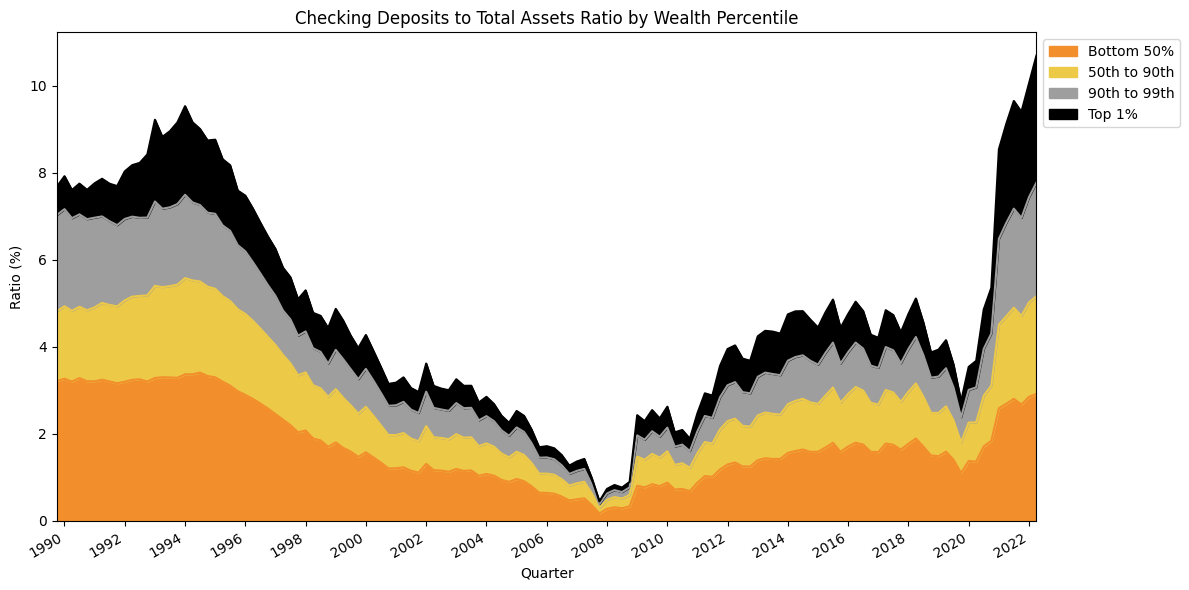

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


def fred_series(series_id: str) -> pd.DataFrame:
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url)
    # Normalize column names; some responses include whitespace or alternate labels.
    df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]
    date_col = "DATE" if "DATE" in df.columns else df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.set_index(date_col)
    # Standardize the data column name to the series id and coerce missing values
    if series_id in df.columns:
        df = df.rename(columns={series_id: series_id})
    else:
        data_col = df.columns[0]
        df = df.rename(columns={data_col: series_id})
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
    return df


# Fetch series as individual dataframes
WFRBSB50194 = fred_series("WFRBSB50194")
WFRBSN40167 = fred_series("WFRBSN40167")
WFRBSN09140 = fred_series("WFRBSN09140")
WFRBST01113 = fred_series("WFRBST01113")
WFRBSB50189 = fred_series("WFRBSB50189")
WFRBSN40162 = fred_series("WFRBSN40162")
WFRBSN09135 = fred_series("WFRBSN09135")
WFRBST01108 = fred_series("WFRBST01108")
BOGZ1FL193020005Q = fred_series("BOGZ1FL193020005Q")
BOGZ1FL192000005A = fred_series("BOGZ1FL192000005A")


def to_quarterly(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Q")
    return out


def to_annual(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Y")
    return out


# Convert to period indexes
WFRBSB50194 = to_quarterly(WFRBSB50194)
WFRBSN40167 = to_quarterly(WFRBSN40167)
WFRBSN09140 = to_quarterly(WFRBSN09140)
WFRBST01113 = to_quarterly(WFRBST01113)
WFRBSB50189 = to_quarterly(WFRBSB50189)
WFRBSN40162 = to_quarterly(WFRBSN40162)
WFRBSN09135 = to_quarterly(WFRBSN09135)
WFRBST01108 = to_quarterly(WFRBST01108)

BOGZ1FL193020005Q = to_quarterly(BOGZ1FL193020005Q)
BOGZ1FL193020005Q = BOGZ1FL193020005Q[
    BOGZ1FL193020005Q.index >= pd.Period("1989Q3", freq="Q")
]

BOGZ1FL192000005A = to_annual(BOGZ1FL192000005A)
BOGZ1FL192000005A = BOGZ1FL192000005A[
    BOGZ1FL192000005A.index >= pd.Period("1989", freq="Y")
]

# Reindex annual data to Q3 and interpolate to quarterly frequency
annual = BOGZ1FL192000005A.copy()
annual.index = annual.index.year
annual_q3 = annual.copy()
annual_q3.index = pd.PeriodIndex([f"{y}Q3" for y in annual.index], freq="Q")
annual_q3 = annual_q3.sort_index()

full_quarters = pd.period_range(
    start=annual_q3.index.min(), end=annual_q3.index.max(), freq="Q"
)
BOGZ1FL192000005A_mod = annual_q3.reindex(full_quarters)
BOGZ1FL192000005A_mod = BOGZ1FL192000005A_mod.interpolate(method="linear")

# Build cashRatios dataframe
combined = pd.concat(
    [
        WFRBSB50194,
        WFRBSN40167,
        WFRBSN09140,
        WFRBST01113,
        WFRBSB50189,
        WFRBSN40162,
        WFRBSN09135,
        WFRBST01108,
        BOGZ1FL193020005Q,
        BOGZ1FL192000005A_mod,
    ],
    axis=1,
).dropna()

cashRatios = pd.DataFrame(index=combined.index)

cashRatios["Bottom 50%"] = (
    combined["WFRBSB50194"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBSB50189"] * combined["BOGZ1FL192000005A"])

cashRatios["50th to 90th"] = (
    combined["WFRBSN40167"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBSN40162"] * combined["BOGZ1FL192000005A"])

cashRatios["90th to 99th"] = (
    combined["WFRBSN09140"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBSN09135"] * combined["BOGZ1FL192000005A"])

cashRatios["Top 1%"] = (
    combined["WFRBST01113"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBST01108"] * combined["BOGZ1FL192000005A"])

# Express as percent
cashRatios = cashRatios * 100

# Stacked area chart
cashRatios_plot = cashRatios.copy()
cashRatios_plot.index = cashRatios_plot.index.to_timestamp(how="end")

# Ensure column order matches desired color order
cashRatios_plot = cashRatios_plot[["Bottom 50%", "50th to 90th", "90th to 99th", "Top 1%"]]

colors = ["#F28E2B", "#EDC948", "#9E9E9E", "#000000"]
ax = cashRatios_plot.plot.area(stacked=True, figsize=(12, 6), color=colors)
ax.set_title("Checking Deposits to Total Assets Ratio by Wealth Percentile")
ax.set_xlabel("Quarter")
ax.set_ylabel("Ratio (%)")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))

# Tighten x-axis to data range and increase tick density to every 2 years
ax.set_xlim(cashRatios_plot.index.min(), cashRatios_plot.index.max())
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()


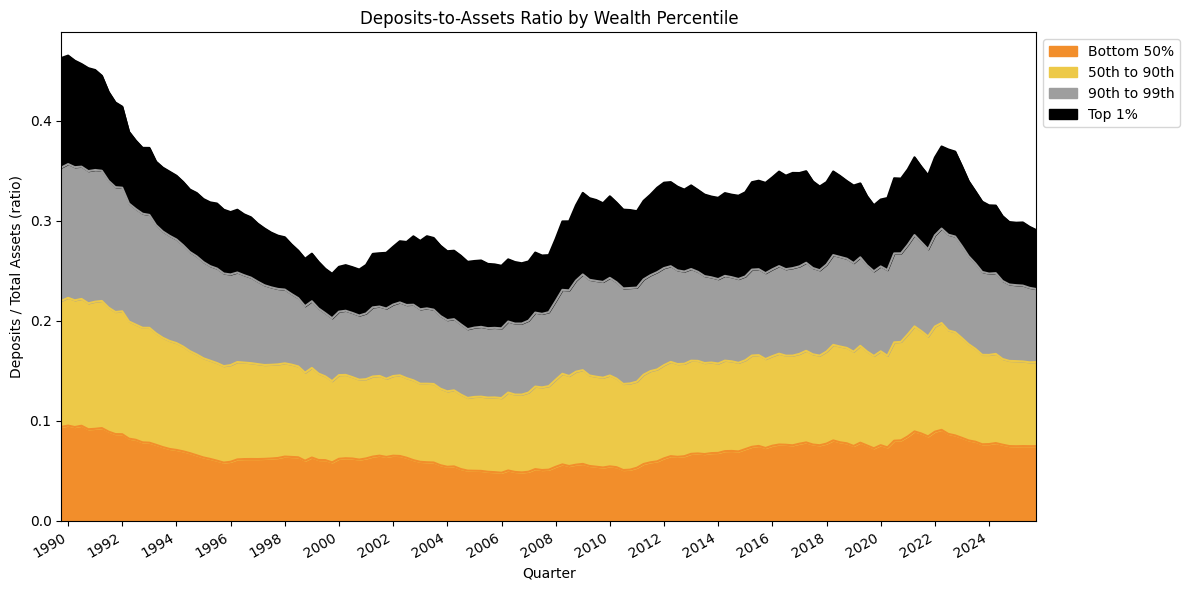

In [4]:
# Alternative chart: deposit level series as a share of total assets by percentile
WFRBLDEB50 = to_quarterly(fred_series("WFRBLDEB50"))
WFRBLDEN40 = to_quarterly(fred_series("WFRBLDEN40"))
WFRBLDEN09 = to_quarterly(fred_series("WFRBLDEN09"))
WFRBLTOP1DE = to_quarterly(fred_series("WFRBLTOP1DE"))

combined_deposits = pd.concat(
    [
        WFRBLDEB50,
        WFRBLDEN40,
        WFRBLDEN09,
        WFRBLTOP1DE,
        WFRBSB50189,
        WFRBSN40162,
        WFRBSN09135,
        WFRBST01108,
        BOGZ1FL192000005A_mod,
    ],
    axis=1,
).dropna()

# Keep the same quarterly start point used in the first chart.
combined_deposits = combined_deposits[
    combined_deposits.index >= pd.Period("1989Q3", freq="Q")
]

depositAssetRatios = pd.DataFrame(index=combined_deposits.index)

depositAssetRatios["Bottom 50%"] = combined_deposits["WFRBLDEB50"] / (
    (combined_deposits["WFRBSB50189"] / 100) * combined_deposits["BOGZ1FL192000005A"]
)

depositAssetRatios["50th to 90th"] = combined_deposits["WFRBLDEN40"] / (
    (combined_deposits["WFRBSN40162"] / 100) * combined_deposits["BOGZ1FL192000005A"]
)

depositAssetRatios["90th to 99th"] = combined_deposits["WFRBLDEN09"] / (
    (combined_deposits["WFRBSN09135"] / 100) * combined_deposits["BOGZ1FL192000005A"]
)

depositAssetRatios["Top 1%"] = combined_deposits["WFRBLTOP1DE"] / (
    (combined_deposits["WFRBST01108"] / 100) * combined_deposits["BOGZ1FL192000005A"]
)

# Keep as ratio values; e.g., 0.09 means 9%.

depositAssetRatios_plot = depositAssetRatios[
    ["Bottom 50%", "50th to 90th", "90th to 99th", "Top 1%"]
].copy()
depositAssetRatios_plot.index = depositAssetRatios_plot.index.to_timestamp(how="end")

import matplotlib.dates as mdates

colors = ["#F28E2B", "#EDC948", "#9E9E9E", "#000000"]
ax = depositAssetRatios_plot.plot.area(stacked=True, figsize=(12, 6), color=colors)
ax.set_title("Deposits-to-Assets Ratio by Wealth Percentile")
ax.set_xlabel("Quarter")
ax.set_ylabel("Deposits / Total Assets (ratio)")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))

ax.set_xlim(depositAssetRatios_plot.index.min(), depositAssetRatios_plot.index.max())
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()


In [5]:
FEDFUNDS = fred_series("FEDFUNDS")

avg_fedfunds_rate = FEDFUNDS["FEDFUNDS"].dropna().mean()
start_date = FEDFUNDS.index.min().date()
end_date = FEDFUNDS.index.max().date()

print(
    f"Average FEDFUNDS rate over full history ({start_date} to {end_date}): "
    f"{avg_fedfunds_rate:.4f}%"
)


Average FEDFUNDS rate over full history (1954-07-01 to 2026-03-01): 4.6004%


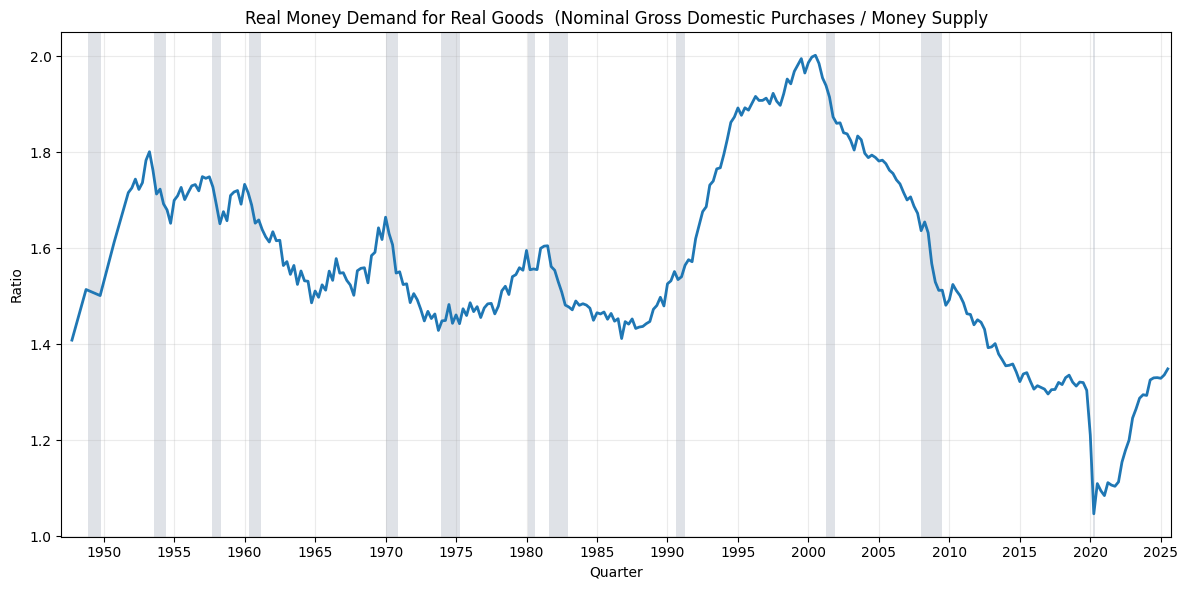

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("\ufeff") for c in df.columns]
        date_col = "DATE" if "DATE" in df.columns else df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.set_index(date_col)
        data_col = series_id if series_id in df.columns else df.columns[0]
        df = df.rename(columns={data_col: series_id})
        df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
        return df

if "to_quarterly" not in globals():
    def to_quarterly(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out.index = out.index.to_period("Q")
        return out.groupby(level=0).mean()


def to_annual(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Y")
    return out.groupby(level=0).mean()


def annual_to_quarterly_linear(df_annual: pd.DataFrame) -> pd.DataFrame:
    annual = df_annual.copy().dropna()
    annual.index = pd.PeriodIndex([f"{p.year}Q4" for p in annual.index], freq="Q")
    full_q = pd.period_range(annual.index.min(), annual.index.max(), freq="Q")
    return annual.reindex(full_q).interpolate(method="linear")


def us_recession_spans() -> list[tuple[pd.Timestamp, pd.Timestamp]]:
    usrec = fred_series("USREC")
    rec = usrec["USREC"].dropna().astype(float)

    spans = []
    in_recession = False
    recession_start = None

    for dt, val in rec.items():
        if val >= 0.5 and not in_recession:
            recession_start = dt
            in_recession = True
        elif val < 0.5 and in_recession:
            spans.append((recession_start, dt))
            in_recession = False

    if in_recession and recession_start is not None:
        spans.append((recession_start, rec.index.max() + pd.offsets.MonthBegin(1)))

    return spans


FSDP = to_quarterly(fred_series("FSDP"))
BOGZ1FL703130005Q = to_quarterly(fred_series("BOGZ1FL703130005Q"))
BOGZ1FL703127005Q = to_quarterly(fred_series("BOGZ1FL703127005Q"))
BOGZ1FL713125005A = annual_to_quarterly_linear(to_annual(fred_series("BOGZ1FL713125005A")))

ratio_df = pd.concat(
    [FSDP, BOGZ1FL703130005Q, BOGZ1FL703127005Q, BOGZ1FL713125005A], axis=1
).dropna()
ratio_df["ratio"] = (ratio_df["FSDP"] * 1000) / (
    ratio_df["BOGZ1FL703130005Q"]
    + ratio_df["BOGZ1FL703127005Q"]
    + ratio_df["BOGZ1FL713125005A"]
)

start_q = pd.Period("1947Q1", freq="Q")
end_q = pd.Period("2025Q3", freq="Q")
ratio_window = ratio_df.loc[start_q:end_q, ["ratio"]].dropna()

ratio_plot = ratio_window.copy()
ratio_plot.index = ratio_plot.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ratio_plot.index, ratio_plot["ratio"], color="#1f77b4", linewidth=2)
ax.set_title(
    "Real Money Demand for Real Goods  (Nominal Gross Domestic Purchases / "
    "Money Supply"
)
ax.set_xlabel("Quarter")
ax.set_ylabel("Ratio")
ax.grid(alpha=0.25)

x_start = start_q.start_time
x_end = end_q.end_time
for rec_start, rec_end in us_recession_spans():
    span_start = max(rec_start, x_start)
    span_end = min(rec_end, x_end)
    if span_start < span_end:
        ax.axvspan(span_start, span_end, color="#c0c7d1", alpha=0.5, lw=0)

ax.set_xlim(x_start, x_end)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()


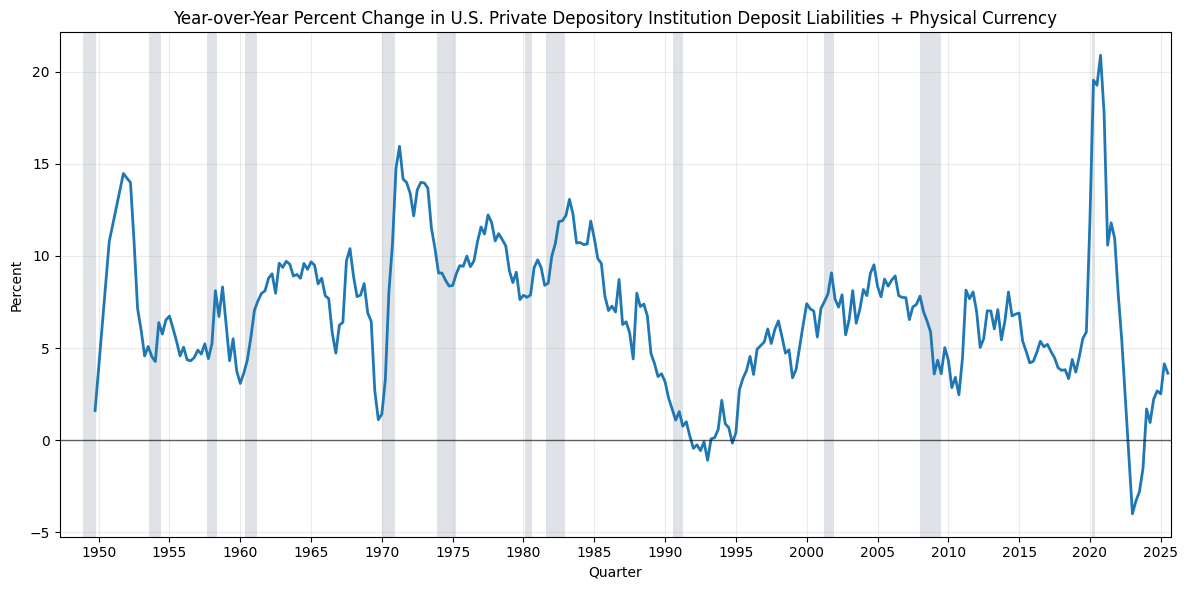

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]
        date_col = "DATE" if "DATE" in df.columns else df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.set_index(date_col)
        data_col = series_id if series_id in df.columns else df.columns[0]
        df = df.rename(columns={data_col: series_id})
        df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
        return df

if "to_quarterly" not in globals():
    def to_quarterly(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out.index = out.index.to_period("Q")
        return out.groupby(level=0).mean()

if "to_annual" not in globals():
    def to_annual(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out.index = out.index.to_period("Y")
        return out.groupby(level=0).mean()

if "annual_to_quarterly_linear" not in globals():
    def annual_to_quarterly_linear(df_annual: pd.DataFrame) -> pd.DataFrame:
        annual = df_annual.copy().dropna()
        annual.index = pd.PeriodIndex([f"{p.year}Q4" for p in annual.index], freq="Q")
        full_q = pd.period_range(annual.index.min(), annual.index.max(), freq="Q")
        return annual.reindex(full_q).interpolate(method="linear")

if "us_recession_spans" not in globals():
    def us_recession_spans() -> list[tuple[pd.Timestamp, pd.Timestamp]]:
        usrec = fred_series("USREC")
        rec = usrec["USREC"].dropna().astype(float)

        spans = []
        in_recession = False
        recession_start = None

        for dt, val in rec.items():
            if val >= 0.5 and not in_recession:
                recession_start = dt
                in_recession = True
            elif val < 0.5 and in_recession:
                spans.append((recession_start, dt))
                in_recession = False

        if in_recession and recession_start is not None:
            spans.append((recession_start, rec.index.max() + pd.offsets.MonthBegin(1)))

        return spans


BOGZ1FL703130005Q = to_quarterly(fred_series("BOGZ1FL703130005Q"))
BOGZ1FL703127005Q = to_quarterly(fred_series("BOGZ1FL703127005Q"))
BOGZ1FL713125005A = annual_to_quarterly_linear(to_annual(fred_series("BOGZ1FL713125005A")))

deposits_df = pd.concat(
    [BOGZ1FL703130005Q, BOGZ1FL703127005Q, BOGZ1FL713125005A], axis=1
).dropna()
deposits_df["total_deposit_liabilities_plus_currency"] = (
    deposits_df["BOGZ1FL703130005Q"]
    + deposits_df["BOGZ1FL703127005Q"]
    + deposits_df["BOGZ1FL713125005A"]
)

# Year-over-year percent change for quarterly data (t vs t-4).
deposits_df["yoy_pct_change"] = (
    (
        deposits_df["total_deposit_liabilities_plus_currency"]
        / deposits_df["total_deposit_liabilities_plus_currency"].shift(4)
    )
    - 1
) * 100

start_q = pd.Period("1947Q2", freq="Q")
end_q = pd.Period("2025Q3", freq="Q")
growth_window = deposits_df.loc[start_q:end_q, ["yoy_pct_change"]].dropna()

growth_plot = growth_window.copy()
growth_plot.index = growth_plot.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    growth_plot.index,
    growth_plot["yoy_pct_change"],
    color="#1f77b4",
    linewidth=2,
)
ax.set_title(
    "Year-over-Year Percent Change in U.S. Private Depository Institution "
    "Deposit Liabilities + Physical Currency"
)
ax.set_xlabel("Quarter")
ax.set_ylabel("Percent")
ax.axhline(0, color="black", linewidth=1, alpha=0.6)
ax.grid(alpha=0.25)

x_start = start_q.start_time
x_end = end_q.end_time
for rec_start, rec_end in us_recession_spans():
    span_start = max(rec_start, x_start)
    span_end = min(rec_end, x_end)
    if span_start < span_end:
        ax.axvspan(span_start, span_end, color="#c0c7d1", alpha=0.5, lw=0)

ax.set_xlim(x_start, x_end)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()



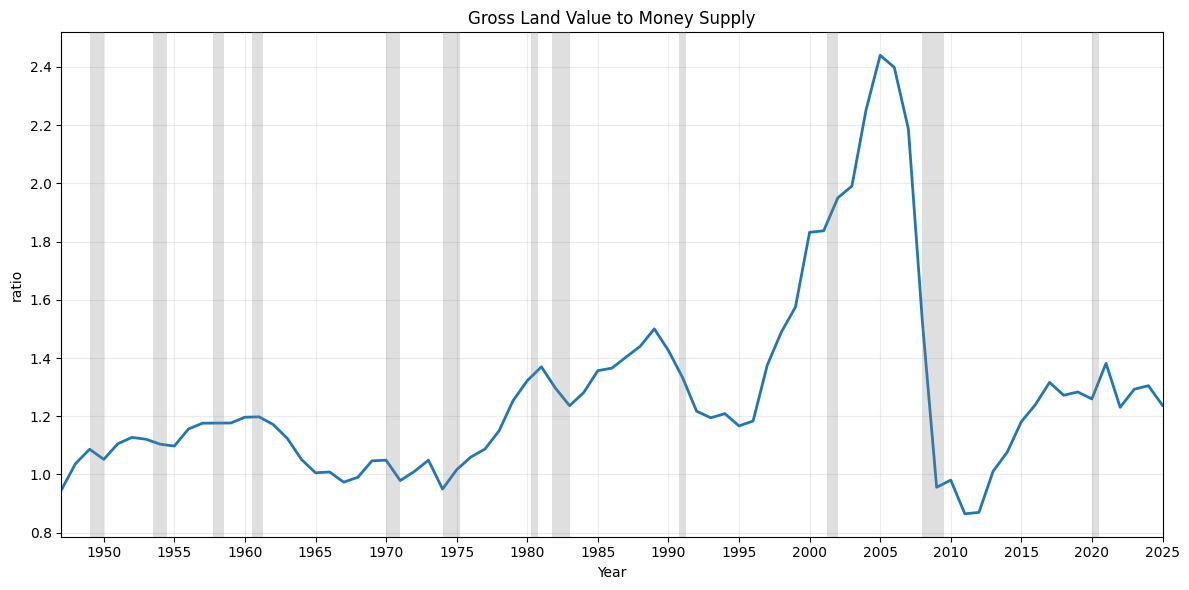

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]

        date_col = "DATE" if "DATE" in df.columns else df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        if df[date_col].isna().all():
            raise ValueError(
                f"FRED response for {series_id} does not contain a parseable date column. "
                f"Columns: {list(df.columns)}"
            )
        df = df.set_index(date_col)

        if series_id in df.columns:
            data_col = series_id
        else:
            candidate_cols = [c for c in df.columns if c != date_col]
            if not candidate_cols:
                raise ValueError(
                    f"FRED response for {series_id} has no data column. Columns: {list(df.columns)}"
                )
            data_col = candidate_cols[0]

        df[series_id] = pd.to_numeric(df[data_col], errors="coerce")
        return df[[series_id]]


def to_annual_mean(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Y")
    return out.groupby(level=0).mean()


def recession_spans() -> list[tuple[pd.Timestamp, pd.Timestamp]]:
    rec = fred_series("USRECQ")
    rec.index = rec.index.to_period("Q")
    s = pd.to_numeric(rec["USRECQ"], errors="coerce").fillna(0).astype(int).sort_index()

    spans: list[tuple[pd.Timestamp, pd.Timestamp]] = []
    in_recession = False
    start = None
    for period, val in s.items():
        if val == 1 and not in_recession:
            start = period.to_timestamp(how="start")
            in_recession = True
        elif val == 0 and in_recession:
            end = period.to_timestamp(how="start")
            spans.append((start, end))
            in_recession = False
    if in_recession and start is not None:
        spans.append((start, (s.index[-1] + 1).to_timestamp(how="start")))
    return spans


BOGZ1FL105010005A = to_annual_mean(fred_series("BOGZ1FL105010005A"))
BOGZ1FL115010005A = to_annual_mean(fred_series("BOGZ1FL115010005A"))
BOGZ1LM155035015A = to_annual_mean(fred_series("BOGZ1LM155035015A"))
BOGZ1LM165035005A = to_annual_mean(fred_series("BOGZ1LM165035005A"))
BOGZ1LM155012665A = to_annual_mean(fred_series("BOGZ1LM155012665A"))
BOGZ1FL165012665A = to_annual_mean(fred_series("BOGZ1FL165012665A"))
BOGZ1FL165013665A = to_annual_mean(fred_series("BOGZ1FL165013665A"))
BOGZ1FL703130005Q = to_annual_mean(fred_series("BOGZ1FL703130005Q"))
BOGZ1FL703127005Q = to_annual_mean(fred_series("BOGZ1FL703127005Q"))
BOGZ1FL713125005A = to_annual_mean(fred_series("BOGZ1FL713125005A"))

ratio_df = pd.concat(
    [
        BOGZ1FL105010005A,
        BOGZ1FL115010005A,
        BOGZ1LM155035015A,
        BOGZ1LM165035005A,
        BOGZ1LM155012665A,
        BOGZ1FL165012665A,
        BOGZ1FL165013665A,
        BOGZ1FL703130005Q,
        BOGZ1FL703127005Q,
        BOGZ1FL713125005A,
    ],
    axis=1,
).dropna()
ratio_df["gross_commercial_land_value_adjusted"] = (
    ratio_df["BOGZ1FL105010005A"]
    + ratio_df["BOGZ1FL115010005A"]
    + ratio_df["BOGZ1LM155035015A"]
    + ratio_df["BOGZ1LM165035005A"]
    - ratio_df["BOGZ1LM155012665A"]
    - ratio_df["BOGZ1FL165012665A"]
    - ratio_df["BOGZ1FL165013665A"]
)
ratio_df["money_supply_proxy"] = (
    ratio_df["BOGZ1FL703130005Q"]
    + ratio_df["BOGZ1FL703127005Q"]
    + ratio_df["BOGZ1FL713125005A"]
)
ratio_df = ratio_df[ratio_df["money_supply_proxy"] != 0]
ratio_df["Gross_Commercial_Land_Value_to_Money_Supply"] = (
    ratio_df["gross_commercial_land_value_adjusted"] / ratio_df["money_supply_proxy"]
)

start_y = pd.Period("1947", freq="Y")
end_y = pd.Period("2025", freq="Y")
series = ratio_df.loc[
    start_y:end_y, "Gross_Commercial_Land_Value_to_Money_Supply"
].dropna()

plot = series.copy()
plot.index = plot.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot.index, plot.values, color="#1f77b4", linewidth=2)
for rec_start, rec_end in recession_spans():
    ax.axvspan(rec_start, rec_end, color="gray", alpha=0.25, linewidth=0, zorder=5)
ax.set_xlim(max(pd.Timestamp("1947-01-01"), plot.index.min()), plot.index.max())
ax.set_title("Gross Land Value to Money Supply")
ax.set_xlabel("Year")
ax.set_ylabel("ratio")
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


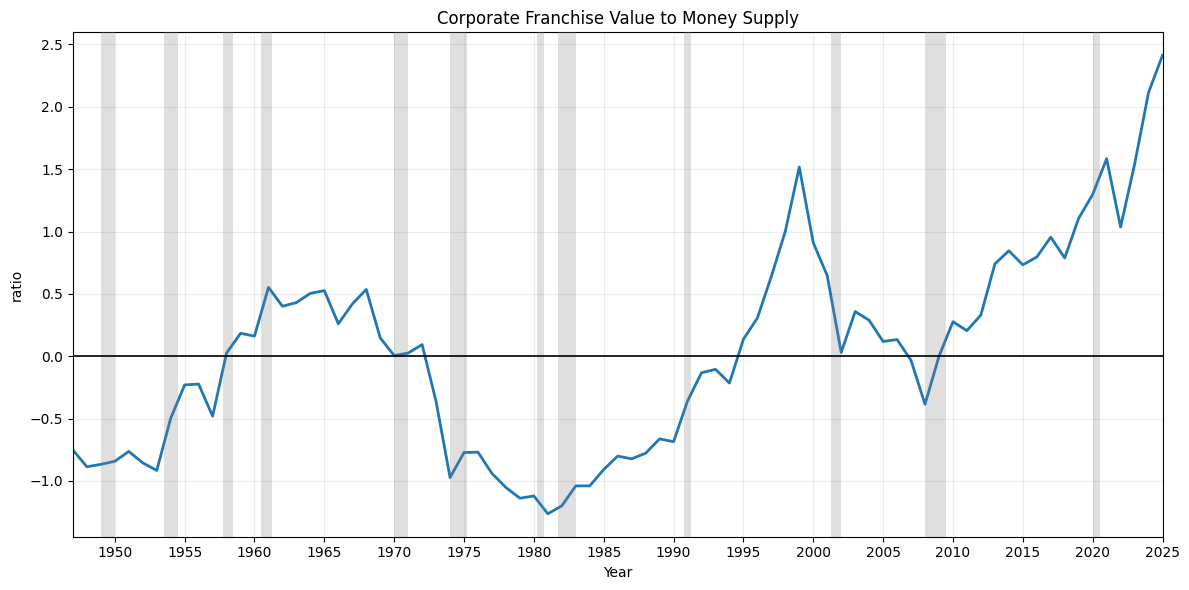

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]

        date_col = "DATE" if "DATE" in df.columns else df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        if df[date_col].isna().all():
            raise ValueError(
                f"FRED response for {series_id} does not contain a parseable date column. "
                f"Columns: {list(df.columns)}"
            )
        df = df.set_index(date_col)

        if series_id in df.columns:
            data_col = series_id
        else:
            candidate_cols = [c for c in df.columns if c != date_col]
            if not candidate_cols:
                raise ValueError(
                    f"FRED response for {series_id} has no data column. Columns: {list(df.columns)}"
                )
            data_col = candidate_cols[0]

        df[series_id] = pd.to_numeric(df[data_col], errors="coerce")
        return df[[series_id]]


def to_annual_mean(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Y")
    return out.groupby(level=0).mean()


def recession_spans() -> list[tuple[pd.Timestamp, pd.Timestamp]]:
    rec = fred_series("USRECQ")
    rec.index = rec.index.to_period("Q")
    s = pd.to_numeric(rec["USRECQ"], errors="coerce").fillna(0).astype(int).sort_index()

    spans: list[tuple[pd.Timestamp, pd.Timestamp]] = []
    in_recession = False
    start = None
    for period, val in s.items():
        if val == 1 and not in_recession:
            start = period.to_timestamp(how="start")
            in_recession = True
        elif val == 0 and in_recession:
            end = period.to_timestamp(how="start")
            spans.append((start, end))
            in_recession = False
    if in_recession and start is not None:
        spans.append((start, (s.index[-1] + 1).to_timestamp(how="start")))
    return spans


NCBIMTA027N = to_annual_mean(fred_series("NCBIMTA027N"))
FBNWMTA027N = to_annual_mean(fred_series("FBNWMTA027N"))
BOGZ1FL703130005Q = to_annual_mean(fred_series("BOGZ1FL703130005Q"))
BOGZ1FL703127005Q = to_annual_mean(fred_series("BOGZ1FL703127005Q"))
BOGZ1FL713125005A = to_annual_mean(fred_series("BOGZ1FL713125005A"))

ratio_df = pd.concat(
    [
        NCBIMTA027N,
        FBNWMTA027N,
        BOGZ1FL703130005Q,
        BOGZ1FL703127005Q,
        BOGZ1FL713125005A,
    ],
    axis=1,
).dropna()
ratio_df["money_supply_proxy"] = (
    ratio_df["BOGZ1FL703130005Q"]
    + ratio_df["BOGZ1FL703127005Q"]
    + ratio_df["BOGZ1FL713125005A"]
)
ratio_df = ratio_df[ratio_df["money_supply_proxy"] != 0]
ratio_df["Corporate_Growth_Equity_to_Money_Supply"] = (
    -1.0 * (ratio_df["NCBIMTA027N"] + ratio_df["FBNWMTA027N"]) / ratio_df["money_supply_proxy"]
)

start_y = pd.Period("1947", freq="Y")
end_y = pd.Period("2025", freq="Y")
series = ratio_df.loc[start_y:end_y, "Corporate_Growth_Equity_to_Money_Supply"].dropna()

plot = series.copy()
plot.index = plot.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot.index, plot.values, color="#1f77b4", linewidth=2)
for rec_start, rec_end in recession_spans():
    ax.axvspan(rec_start, rec_end, color="gray", alpha=0.25, linewidth=0, zorder=5)
ax.axhline(0, color="black", linewidth=1.2, zorder=6)
ax.set_xlim(max(pd.Timestamp("1947-01-01"), plot.index.min()), plot.index.max())
ax.set_title("Corporate Franchise Value to Money Supply")
ax.set_xlabel("Year")
ax.set_ylabel("ratio")
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


In [10]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from IPython.display import display

base_dir = Path("CPI_relative_importance")


def normalize_label(text) -> str:
    s = str(text).replace("\u2019", "'").replace(".", " ").lower()
    return " ".join(s.split())


def normalize_key(text) -> str:
    return "".join(ch for ch in normalize_label(text).replace("'", "") if ch.isalnum())


def to_float(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    s = (
        str(value)
        .strip()
        .replace(",", "")
        .replace("\u2212", "-")
        .replace(" .", ".")
        .replace(". ", ".")
    )
    s = "".join(ch for ch in s if ch.isdigit() or ch in ".-")
    if s.startswith("."):
        s = "0" + s
    if s.startswith("-."):
        s = "-0" + s[1:]
    if s.count(".") > 1:
        first_dot = s.find(".")
        s = s[: first_dot + 1] + s[first_dot + 1 :].replace(".", "")

    try:
        return float(s)
    except ValueError:
        return np.nan


def entries_from_column(df: pd.DataFrame, label_col, value_col) -> list[dict]:
    rows = []
    for label, value in zip(df[label_col], df[value_col]):
        val = to_float(value)
        if pd.isna(val):
            continue
        key = normalize_key(label)
        if not key:
            continue
        rows.append({"label": str(label), "key": key, "value": val})
    return rows


def pick_exact(entries: list[dict], keys: set[str]):
    vals = [e["value"] for e in entries if e["key"] in keys]
    return max(vals) if vals else np.nan


def pick_oer(entries: list[dict]):
    candidates = [
        e
        for e in entries
        if "ownersequivalentrent" in e["key"] and "unsampled" not in e["key"]
    ]
    if not candidates:
        return np.nan

    def score(e):
        key = e["key"]
        if "ofresidences" in key:
            return 0
        if key == "ownersequivalentrent":
            return 1
        if "ofprimaryresidence" in key:
            return 2
        return 3

    candidates = sorted(candidates, key=lambda e: (score(e), -e["value"]))
    return candidates[0]["value"]


def extract_targets(entries: list[dict]):
    durables = pick_exact(entries, {"durables"})
    nondurables = pick_exact(entries, {"nondurables"})
    services = pick_exact(entries, {"services", "allservices"})
    oer = pick_oer(entries)
    return durables, nondurables, services, oer


def pick_owner_occupied_base(entries: list[dict]):
    """
    Pick the broad pre-1983 owner-occupied housing aggregate used for OER backcasting.

    Priority order:
    1) Homeowners' costs
    2) Homeownership
    3) Home purchase and upkeep

    We intentionally do NOT build this from subtraction residuals to avoid nested
    item double-count issues (for example, taxes and insurance vs property-tax
    subrows) and to keep the base aligned with the broad historical aggregate.
    """
    candidates = [
        ("homeownerscosts", {"homeownerscosts", "homeownerscost"}),
        ("homeownership", {"homeownership"}),
        (
            "homepurchaseandupkeep",
            {"homepurchaseandupkeep", "homepurchaseupkeep"},
        ),
    ]
    for canonical, keys in candidates:
        value = pick_exact(entries, keys)
        if pd.notna(value):
            return value, canonical
    return np.nan, ""


# (a) historical workbook parser: 1947-1986
def parse_historical_workbook(base: Path) -> dict[int, dict]:
    file_path = base / "historical-relative-importance-1947-1986.xlsx"
    out = {}

    def pack(entries, year, source, note=""):
        d, n, s, o = extract_targets(entries)
        owner_base, owner_base_label = pick_owner_occupied_base(entries)
        return {
            "durables": d,
            "nondurables": n,
            "services": s,
            "owners_equivalent_rent": o,
            "owner_occupied_base": owner_base,
            "owner_occupied_base_label": owner_base_label,
            "source_file": source,
            "note": note,
        }

    # 1947-1949 average sheet expanded to three yearly rows.
    df = pd.read_excel(file_path, sheet_name="1947-1949", header=1)
    entries = entries_from_column(df, df.columns[0], df.columns[1])
    packed = pack(
        entries,
        1949,
        "historical-relative-importance-1947-1986.xlsx:1947-1949",
        "Expanded from 1947-1949 average sheet.",
    )
    for year in [1947, 1948, 1949]:
        out[year] = dict(packed)

    # 1951 exists but requested aggregates are not directly identifiable.
    out[1951] = {
        "durables": np.nan,
        "nondurables": np.nan,
        "services": np.nan,
        "owners_equivalent_rent": np.nan,
        "owner_occupied_base": np.nan,
        "owner_occupied_base_label": "",
        "source_file": "historical-relative-importance-1947-1986.xlsx:1951",
        "note": "No directly identifiable aggregate rows for requested categories; interpolated from adjacent years.",
    }

    # Multi-year sheets with explicit December year columns.
    for sheet in ["1952-1960", "1961-1976"]:
        df = pd.read_excel(file_path, sheet_name=sheet, header=1)
        label_col = df.columns[0]
        for col in df.columns[1:]:
            m = re.search(r"(19\d{2})", str(col))
            if not m:
                continue
            year = int(m.group(1))
            entries = entries_from_column(df, label_col, col)
            out[year] = pack(
                entries,
                year,
                f"historical-relative-importance-1947-1986.xlsx:{sheet}",
                "",
            )

    # 1977-1979 sheet: use All Urban Consumers columns.
    df = pd.read_excel(file_path, sheet_name="1977-1979", header=1)
    label_col = df.columns[0]
    for col in df.columns[1:]:
        col_str = str(col)
        if "all urban consumers" not in col_str.lower():
            continue
        m = re.search(r"(19\d{2})", col_str)
        if not m:
            continue
        year = int(m.group(1))
        entries = entries_from_column(df, label_col, col)
        out[year] = pack(
            entries,
            year,
            "historical-relative-importance-1947-1986.xlsx:1977-1979",
            "",
        )

    # 1980-1981: two-level headers.
    df = pd.read_excel(file_path, sheet_name="1980-1981", header=[1, 2])
    label_col = df.columns[0]
    for col in df.columns[1:]:
        top = str(col[0]).lower()
        bottom = str(col[1])
        if "all urban consumers" not in top:
            continue
        m = re.search(r"(19\d{2})", bottom)
        if not m:
            continue
        year = int(m.group(1))
        entries = entries_from_column(df, label_col, col)
        out[year] = pack(
            entries,
            year,
            "historical-relative-importance-1947-1986.xlsx:1980-1981",
            "",
        )

    # 1982-1985 single-year sheets: use main/current CPI-U column only.
    for sheet in ["1982", "1983", "1984", "1985"]:
        df = pd.read_excel(file_path, sheet_name=sheet, header=1)
        label_col = df.columns[0]
        cpi_u_col = [
            c
            for c in df.columns[1:]
            if "cpi-u" in str(c).lower() and "old series" not in str(c).lower()
        ][0]
        year = int(sheet)
        entries = entries_from_column(df, label_col, cpi_u_col)
        out[year] = pack(
            entries,
            year,
            f"historical-relative-importance-1947-1986.xlsx:{sheet}",
            "",
        )

    # 1986 has a different header row offset.
    df = pd.read_excel(file_path, sheet_name="1986", header=2)
    label_col = df.columns[0]
    cpi_u_col = [c for c in df.columns[1:] if "cpi-u" in str(c).lower()][0]
    entries = entries_from_column(df, label_col, cpi_u_col)
    out[1986] = pack(
        entries,
        1986,
        "historical-relative-importance-1947-1986.xlsx:1986",
        "",
    )

    return out


# Common TXT row parser used by 1987-1999 and 2000-2019 families.
def parse_txt_rows(path: Path) -> list[dict]:
    rows = []
    for raw_line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        parts = raw_line.strip().split()
        if len(parts) < 3:
            continue

        cpi_u = to_float(parts[-2])
        cpi_w = to_float(parts[-1])
        if pd.isna(cpi_u) or pd.isna(cpi_w):
            continue

        lead = parts[:-2]
        if not lead:
            continue

        code = None
        if re.fullmatch(r"[A-Z0-9]{2,8}", lead[0] or ""):
            code = lead[0]
            label = " ".join(lead[1:])
            if not label:
                continue
        else:
            label = " ".join(lead)

        label = " ".join(label.replace(".", " ").split())
        rows.append(
            {
                "code": code,
                "label": label,
                "key": normalize_key(label),
                "cpi_u": cpi_u,
                "cpi_w": cpi_w,
            }
        )
    return rows


# (b) 1987-1999 TXT parser
def parse_1987_1999_txt(base: Path) -> dict[int, dict]:
    out = {}
    for year in range(1987, 2000):
        file_path = base / f"{year}.txt"
        rows = parse_txt_rows(file_path)
        entries = [{"label": r["label"], "key": r["key"], "value": r["cpi_u"]} for r in rows]

        d, n, s, o = extract_targets(entries)
        by_code = {r["code"]: r["cpi_u"] for r in rows if r["code"]}
        d = by_code.get("SAD", d)
        n = by_code.get("SAN", n)
        s = by_code.get("SAS", s)
        o = by_code.get("SE2201", o)

        out[year] = {
            "durables": d,
            "nondurables": n,
            "services": s,
            "owners_equivalent_rent": o,
            "owner_occupied_base": np.nan,
            "owner_occupied_base_label": "",
            "source_file": file_path.name,
            "note": "",
        }
    return out


# (c) 2000-2019 TXT parser
def parse_2000_2019_txt(base: Path) -> dict[int, dict]:
    out = {}
    for year in range(2000, 2020):
        file_path = base / f"{year}.txt"
        rows = parse_txt_rows(file_path)
        entries = [{"label": r["label"], "key": r["key"], "value": r["cpi_u"]} for r in rows]
        d, n, s, o = extract_targets(entries)

        out[year] = {
            "durables": d,
            "nondurables": n,
            "services": s,
            "owners_equivalent_rent": o,
            "owner_occupied_base": np.nan,
            "owner_occupied_base_label": "",
            "source_file": file_path.name,
            "note": "",
        }
    return out


# (d) 2020-2025 XLSX parser

def parse_2020_2025_xlsx(base: Path) -> dict[int, dict]:
    out = {}
    for year in range(2020, 2026):
        file_path = base / f"{year}.xlsx"
        df = pd.read_excel(file_path, sheet_name="Table 1", header=3)
        item_col = [c for c in df.columns if "item and group" in str(c).lower()][0]
        cpi_u_col = df.columns[2]

        entries = entries_from_column(df, item_col, cpi_u_col)
        d, n, s, o = extract_targets(entries)

        out[year] = {
            "durables": d,
            "nondurables": n,
            "services": s,
            "owners_equivalent_rent": o,
            "owner_occupied_base": np.nan,
            "owner_occupied_base_label": "",
            "source_file": f"{file_path.name}:Table 1",
            "note": "",
        }
    return out


# Build unified yearly frame.
records = {}
for parser in [
    parse_historical_workbook,
    parse_1987_1999_txt,
    parse_2000_2019_txt,
    parse_2020_2025_xlsx,
]:
    records.update(parser(base_dir))

all_years = list(range(1947, 2026))
working = pd.DataFrame(
    index=all_years,
    columns=[
        "durables",
        "nondurables",
        "services",
        "owners_equivalent_rent",
        "owner_occupied_base",
        "owner_occupied_base_label",
        "source_file",
        "note",
    ],
)

for year, values in records.items():
    for key, val in values.items():
        working.at[year, key] = val

for col in [
    "durables",
    "nondurables",
    "services",
    "owners_equivalent_rent",
    "owner_occupied_base",
]:
    working[col] = pd.to_numeric(working[col], errors="coerce")

# Fill aggregate share gaps by interpolation (required for 1950/1951 and sparse historical years).
missing_before_fill = working[["durables", "nondurables", "services"]].isna().any(axis=1)
for col in ["durables", "nondurables", "services"]:
    working[col] = working[col].interpolate(method="linear", limit_area="inside")

# Required caveats for 1950 and 1951.
if pd.isna(working.at[1950, "source_file"]):
    working.at[1950, "source_file"] = "interpolated_from_adjacent_years"
working.at[1950, "note"] = "1950 unavailable directly; filled by linear interpolation from adjacent years."
working.at[1951, "source_file"] = "historical-relative-importance-1947-1986.xlsx:1951 (interpolated)"
working.at[1951, "note"] = "1951 aggregates not directly identifiable; filled by linear interpolation from adjacent years."

for year in all_years:
    if year in [1950, 1951]:
        continue
    if bool(missing_before_fill.loc[year]):
        base_note = "" if pd.isna(working.at[year, "note"]) else str(working.at[year, "note"]).strip()
        msg = "Some aggregate values missing in source; filled by linear interpolation from adjacent years."
        if msg not in base_note:
            working.at[year, "note"] = (base_note + " " + msg).strip()

for year in [1947, 1948, 1949]:
    base_note = "" if pd.isna(working.at[year, "note"]) else str(working.at[year, "note"]).strip()
    msg = "Expanded from 1947-1949 average sheet."
    if msg not in base_note:
        working.at[year, "note"] = (base_note + " " + msg).strip()

# Build pre-1983 homeowner cost component from mapped broad owner-occupied
# housing aggregates (no residual subtraction).
working["pre_1983_homeowner_cost_component"] = np.nan

anchor_year = 1982
anchor_oer = working.at[anchor_year, "owners_equivalent_rent"]
anchor_base = working.at[anchor_year, "owner_occupied_base"]
if pd.isna(anchor_oer):
    raise AssertionError("1982 explicit OER row missing; cannot calibrate pre-1983 mapping.")
if pd.isna(anchor_base) or anchor_base == 0:
    raise AssertionError("1982 owner-occupied housing aggregate missing; cannot calibrate pre-1983 mapping.")
bridge_factor = anchor_oer / anchor_base

pre_years = [y for y in all_years if y < 1983]
owner_base_pre_observed = working.loc[pre_years, "owner_occupied_base"].copy()
owner_base_pre_filled = owner_base_pre_observed.copy()

# Fill internal gaps first.
owner_base_pre_filled = owner_base_pre_filled.interpolate(method="linear", limit_area="inside")

# Backcast leading missing years from the mapped owner-occupied base series.
valid_idx = owner_base_pre_filled.dropna().index.tolist()
if valid_idx:
    first_valid = valid_idx[0]
    if len(valid_idx) >= 2:
        second_valid = valid_idx[1]
        year_gap = second_valid - first_valid
        slope = (owner_base_pre_filled.at[second_valid] - owner_base_pre_filled.at[first_valid]) / year_gap
    else:
        slope = 0.0
    for year in pre_years:
        if year >= first_valid:
            continue
        owner_base_pre_filled.at[year] = owner_base_pre_filled.at[first_valid] - slope * (first_valid - year)
        if owner_base_pre_filled.at[year] < 0:
            owner_base_pre_filled.at[year] = np.nan

# Final guard for any stragglers after backcast.
owner_base_pre_filled = owner_base_pre_filled.interpolate(method="linear", limit_direction="both")
mapped_component_pre = owner_base_pre_filled * bridge_factor

initial_status = {}
for year in pre_years:
    oer_val = working.at[year, "owners_equivalent_rent"]
    observed_base = owner_base_pre_observed.at[year]

    if pd.notna(oer_val):
        component_val = oer_val
        initial_status[year] = "direct_observed_oer"
    else:
        component_val = mapped_component_pre.at[year]
        if pd.notna(observed_base):
            base_label = str(working.at[year, "owner_occupied_base_label"]).strip() or "owner_occupied_base"
            initial_status[year] = f"mapped_from_{base_label}"
        else:
            initial_status[year] = "backcast_or_interpolated_mapped_owner_base"

    working.at[year, "pre_1983_homeowner_cost_component"] = component_val

# Define services_excl_oer with requested rule:
# - use explicit OER whenever present (1983+ and 1982 bridge year)
# - otherwise (pre-1983) subtract mapped/backcast homeowner component
services_excl = []
for year in all_years:
    services_val = working.at[year, "services"]
    oer_val = working.at[year, "owners_equivalent_rent"]
    if pd.notna(oer_val):
        services_excl.append(services_val - oer_val)
    elif year < 1983:
        services_excl.append(services_val - working.at[year, "pre_1983_homeowner_cost_component"])
    else:
        services_excl.append(np.nan)
working["services_excl_oer"] = services_excl

# Notes for proxy/estimate provenance.
for year in pre_years:
    status = initial_status.get(year)
    if status is None:
        continue

    base_note = "" if pd.isna(working.at[year, "note"]) else str(working.at[year, "note"]).strip()

    if status == "direct_observed_oer":
        extra = "Pre-1983 homeowner component uses directly observed OER row (1982 bridge year)."
    elif status.startswith("mapped_from_"):
        mapped_source = status.replace("mapped_from_", "")
        extra = (
            f"Pre-1983 homeowner component is estimated by mapping '{mapped_source}' to the OER concept "
            f"with a 1982 bridge factor ({bridge_factor:.6f})."
        )
    else:
        extra = (
            f"Pre-1983 homeowner component is estimated by interpolation/backcast of the mapped owner-occupied "
            f"housing aggregate using the 1982 bridge factor ({bridge_factor:.6f})."
        )

    if extra not in base_note:
        working.at[year, "note"] = (base_note + " " + extra).strip()

# Final DataFrame (owners_equivalent_rent added back).
cpi_u_relative_importance = working[
    [
        "durables",
        "nondurables",
        "owners_equivalent_rent",
        "pre_1983_homeowner_cost_component",
        "services_excl_oer",
        "source_file",
        "note",
    ]
].copy()
cpi_u_relative_importance.index.name = "year"
cpi_u_relative_importance = cpi_u_relative_importance.sort_index()

# Show compact audit view only (first 15 and last 15 rows).
audit_view = pd.concat(
    [
        cpi_u_relative_importance.head(15),
        cpi_u_relative_importance.tail(15),
    ],
    axis=0,
)
display(audit_view)

# Sanity checks required by prompt
for check_year in [1987, 2000, 2010, 2025]:
    assert check_year in cpi_u_relative_importance.index, f"Missing year {check_year}"
    services_val = working.at[check_year, "services"]
    oer_val = working.at[check_year, "owners_equivalent_rent"]
    assert pd.notna(oer_val), f"Expected explicit OER for {check_year}"
    calc = cpi_u_relative_importance.at[check_year, "services_excl_oer"]
    assert np.isclose(calc, services_val - oer_val, atol=1e-9), (
        f"services_excl_oer mismatch for {check_year}: {calc} vs {services_val - oer_val}"
    )

# Explicit check for 1982 anchor behavior.
assert pd.notna(working.at[1982, "owners_equivalent_rent"]), "1982 OER anchor missing"
assert np.isclose(
    working.at[1982, "services_excl_oer"],
    working.at[1982, "services"] - working.at[1982, "owners_equivalent_rent"],
    atol=1e-9,
), "1982 services_excl_oer does not use explicit OER"

# Additional sanity check requested: pre-1983 homeowner component should be
# high single digits/teens, not around 1.0.
pre_1983_component = working.loc[working.index < 1983, "pre_1983_homeowner_cost_component"].dropna()
assert not pre_1983_component.empty, "Pre-1983 homeowner component is empty."
assert pre_1983_component.median() >= 8.0, (
    f"Pre-1983 homeowner component median too small: {pre_1983_component.median():.3f}"
)
assert pre_1983_component.min() >= 5.0, (
    f"Pre-1983 homeowner component minimum too small: {pre_1983_component.min():.3f}"
)

print(
    "Sanity checks passed for 1987/2000/2010/2025, 1982 anchor handling, "
    "and pre-1983 homeowner component magnitude."
)


,durables,nondurables,owners_equivalent_rent,pre_1983_homeowner_cost_component,services_excl_oer,source_file,note
year,,,,,,,
1947,6.700000,66.200,NaN,11.010857,16.089143,historical-relative-importance-1947-1986.xlsx:...,Expanded from 1947-1949 average sheet. Pre-198...
1948,6.700000,66.200,NaN,11.069166,16.030834,historical-relative-importance-1947-1986.xlsx:...,Expanded from 1947-1949 average sheet. Pre-198...
1949,6.700000,66.200,NaN,11.127476,15.972524,historical-relative-importance-1947-1986.xlsx:...,Expanded from 1947-1949 average sheet. Pre-198...
1950,7.562500,64.350,NaN,11.185786,16.801714,interpolated_from_adjacent_years,1950 unavailable directly; filled by linear in...
1951,8.425000,62.500,NaN,11.244096,17.630904,historical-relative-importance-1947-1986.xlsx:...,1951 aggregates not directly identifiable; fil...
1952,9.287500,60.650,NaN,11.302406,18.460094,historical-relative-importance-1947-1986.xlsx:...,Some aggregate values missing in source; fille...
1953,10.150000,58.800,NaN,11.360716,19.289284,historical-relative-importance-1947-1986.xlsx:...,Some aggregate values missing in source; fille...
1954,11.012500,56.950,NaN,11.632829,19.904671,historical-relative-importance-1947-1986.xlsx:...,Some aggregate values missing in source; fille...
1955,11.875000,55.100,NaN,11.710576,20.714424,historical-relative-importance-1947-1986.xlsx:...,Some aggregate values missing in source; fille...


Sanity checks passed for 1987/2000/2010/2025, 1982 anchor handling, and pre-1983 homeowner component magnitude.


In [11]:
import numpy as np
import pandas as pd
from IPython.display import display

# Fallback loader in case this cell is run before earlier helper cells.
if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]
        date_col = next((c for c in df.columns if c.upper() == "DATE"), df.columns[0])
        value_col = next((c for c in df.columns if str(c).strip().upper() == series_id.upper()), None)
        if value_col is None:
            value_col = next((c for c in df.columns if str(c).strip().upper() != "DATE"), None)
        if value_col is None:
            raise ValueError(f"Could not find value column for {series_id}: {df.columns.tolist()}")
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.dropna(subset=[date_col]).set_index(date_col)
        df[series_id] = pd.to_numeric(df[value_col], errors="coerce")
        return df[[series_id]]


def to_annual(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if isinstance(out.index, pd.PeriodIndex):
        out.index = out.index.asfreq("Y")
    else:
        out.index = pd.to_datetime(out.index, errors="coerce").to_period("Y")
    # If a non-annual series sneaks in, average within year.
    out = out.groupby(out.index).mean(numeric_only=True)
    return out


series_ids = [
    "K1NTOTL1ES000",
    "BOGZ1FL105010005A",
    "BOGZ1FL115010005A",
    "BOGZ1LM145020005A",
    "NCBIMTA027N",
    "FBNWMTA027N",
    "BOGZ1LM112090005A",
    "BOGZ1FL102090005A",
    "BOGZ1FL893061105A",
    "BOGZ1FL893061705A",
    "BOGZ1FL893062005A",
    "BOGZ1FL893063005A",
    "BOGZ1FL883069175A",
    "BOGZ1FL703061105A",
    "BOGZ1FL703061705A",
    "BOGZ1FL703062005A",
    "BOGZ1FL703063005A",
    "BOGZ1FL703069175A",
    "IIPUSNETIA",
]

annual_series = {sid: to_annual(fred_series(sid)) for sid in series_ids}

year_index = pd.period_range("1947", "2024", freq="Y")
combined = pd.concat([annual_series[sid][sid] for sid in series_ids], axis=1).reindex(year_index)

franchise_raw = -1 * (
    combined["NCBIMTA027N"]
    + combined["FBNWMTA027N"]
    + (combined["BOGZ1LM112090005A"] / combined["BOGZ1FL102090005A"]) * combined["NCBIMTA027N"]
)
franchise_component = np.maximum(0, franchise_raw)

debt_component = (
    combined["BOGZ1FL893061105A"]
    + combined["BOGZ1FL893061705A"]
    + combined["BOGZ1FL893062005A"]
    + combined["BOGZ1FL893063005A"]
    + combined["BOGZ1FL883069175A"]
    - combined["BOGZ1FL703061105A"]
    - combined["BOGZ1FL703061705A"]
    - combined["BOGZ1FL703062005A"]
    - combined["BOGZ1FL703063005A"]
    - combined["BOGZ1FL703069175A"]
)

International_Investable = (
    combined["K1NTOTL1ES000"]
    + combined["BOGZ1FL105010005A"]
    + combined["BOGZ1FL115010005A"]
    + combined["BOGZ1LM145020005A"]
    + franchise_component
    + debt_component
)

# Use 0 when IIPUSNETIA is missing so downstream calculations still evaluate.
iipusnetia_for_calc = combined["IIPUSNETIA"].fillna(0)
Net_Domestic_Invested = International_Investable + iipusnetia_for_calc
IIP_Rate = Net_Domestic_Invested / International_Investable.replace(0, np.nan)

IIP_adjustments = pd.DataFrame(
    {
        "IIPed_Nonresidential_Investment_Durables": combined["K1NTOTL1ES000"] * IIP_Rate,
        "IIPed_Business_Land": (
            (combined["BOGZ1FL105010005A"] + combined["BOGZ1FL115010005A"]) * IIP_Rate
        ),
        "IIPed_Inventories": combined["BOGZ1LM145020005A"] * IIP_Rate,
        "IIPed_Franchise_Value": franchise_component * IIP_Rate,
        "IIPed_Debt": debt_component * IIP_Rate,
    },
    index=year_index,
)
IIP_adjustments.index.name = "year"

display(IIP_adjustments)


,IIPed_Nonresidential_Investment_Durables,IIPed_Business_Land,IIPed_Inventories,IIPed_Franchise_Value,IIPed_Debt
year,,,,,
1947,2.657250e+05,1.389840e+05,8.120000e+04,0.000000e+00,1.266580e+05
1948,2.915570e+05,1.499190e+05,8.805000e+04,0.000000e+00,1.318510e+05
1949,2.966710e+05,1.561420e+05,8.275000e+04,0.000000e+00,1.314920e+05
1950,3.358680e+05,1.577700e+05,8.765000e+04,0.000000e+00,1.410440e+05
1951,3.662260e+05,1.756190e+05,1.080250e+05,0.000000e+00,1.480440e+05
...,...,...,...,...,...
2020,2.388700e+07,1.020687e+07,2.578220e+06,3.411724e+07,4.180235e+07
2021,2.619747e+07,1.201962e+07,3.018001e+06,4.491187e+07,4.185400e+07
2022,2.944544e+07,1.042733e+07,3.347823e+06,3.067103e+07,3.865711e+07


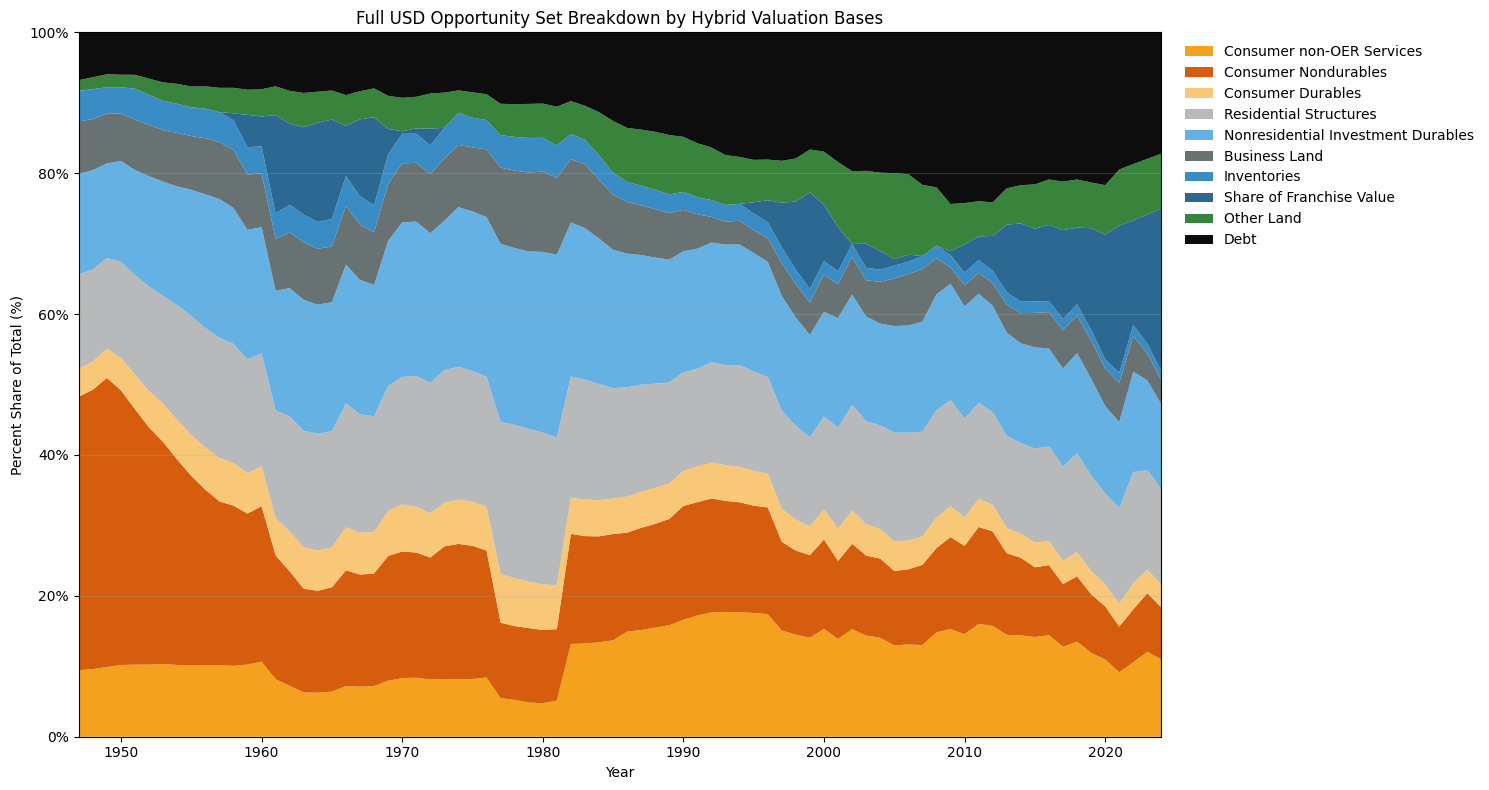

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

if "cpi_u_relative_importance" not in globals():
    raise NameError("cpi_u_relative_importance is not defined. Run the CPI cell first.")
if "IIP_adjustments" not in globals():
    raise NameError("IIP_adjustments is not defined. Run the IIP adjustments cell first.")

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]
        date_col = next((c for c in df.columns if c.upper() == "DATE"), df.columns[0])
        value_col = next((c for c in df.columns if str(c).strip().upper() == series_id.upper()), None)
        if value_col is None:
            value_col = next((c for c in df.columns if str(c).strip().upper() != "DATE"), None)
        if value_col is None:
            raise ValueError(f"Could not find value column for {series_id}: {df.columns.tolist()}")
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.dropna(subset=[date_col]).set_index(date_col)
        df[series_id] = pd.to_numeric(df[value_col], errors="coerce")
        return df[[series_id]]

if "to_annual" not in globals():
    def to_annual(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        if isinstance(out.index, pd.PeriodIndex):
            out.index = out.index.asfreq("Y")
        else:
            out.index = pd.to_datetime(out.index, errors="coerce").to_period("Y")
        return out.groupby(out.index).mean(numeric_only=True)


def to_year_series(obj, col: str | None = None) -> pd.Series:
    s = obj[col] if col is not None else obj
    s = pd.to_numeric(s, errors="coerce")
    idx = s.index
    if isinstance(idx, pd.PeriodIndex):
        years = idx.year
    elif isinstance(idx, pd.DatetimeIndex):
        years = idx.year
    else:
        years = pd.to_numeric(pd.Index(idx), errors="coerce")
    out = pd.Series(s.values, index=years, name=s.name)
    out = out[~pd.isna(out.index)]
    out.index = out.index.astype(int)
    return out.groupby(out.index).mean()


year_index = pd.Index(range(1947, 2025), name="year")

# Prior-cell inputs
cpi_durables = to_year_series(cpi_u_relative_importance, "durables").reindex(year_index)
cpi_nondurables = to_year_series(cpi_u_relative_importance, "nondurables").reindex(year_index)
cpi_services_excl_oer = to_year_series(cpi_u_relative_importance, "services_excl_oer").reindex(year_index)

iip_nonres_durables = to_year_series(IIP_adjustments, "IIPed_Nonresidential_Investment_Durables").reindex(year_index)
iip_business_land = to_year_series(IIP_adjustments, "IIPed_Business_Land").reindex(year_index)
iip_inventories = to_year_series(IIP_adjustments, "IIPed_Inventories").reindex(year_index)
iip_franchise = to_year_series(IIP_adjustments, "IIPed_Franchise_Value").reindex(year_index)
iip_debt = to_year_series(IIP_adjustments, "IIPed_Debt").reindex(year_index)

# New FRED pulls
K1CTOTL1CD000 = to_year_series(to_annual(fred_series("K1CTOTL1CD000")), "K1CTOTL1CD000").reindex(year_index)
K1R53101ES000 = to_year_series(to_annual(fred_series("K1R53101ES000")), "K1R53101ES000").reindex(year_index)

BOGZ1LM155035015A = to_year_series(to_annual(fred_series("BOGZ1LM155035015A")), "BOGZ1LM155035015A").reindex(year_index)
BOGZ1LM165035005A = to_year_series(to_annual(fred_series("BOGZ1LM165035005A")), "BOGZ1LM165035005A").reindex(year_index)
BOGZ1LM155012665A = to_year_series(to_annual(fred_series("BOGZ1LM155012665A")), "BOGZ1LM155012665A").reindex(year_index)
BOGZ1FL165012665A = to_year_series(to_annual(fred_series("BOGZ1FL165012665A")), "BOGZ1FL165012665A").reindex(year_index)
BOGZ1FL165013665A = to_year_series(to_annual(fred_series("BOGZ1FL165013665A")), "BOGZ1FL165013665A").reindex(year_index)

other_land = (
    BOGZ1LM155035015A
    + BOGZ1LM165035005A
    - BOGZ1LM155012665A
    - BOGZ1FL165012665A
    - BOGZ1FL165013665A
)

sectors = pd.DataFrame(
    {
        "Consumer Nondurables": (cpi_nondurables / cpi_durables) * K1CTOTL1CD000,
        "Consumer non-OER Services": (cpi_services_excl_oer / cpi_durables) * K1CTOTL1CD000,
        "Consumer Durables": K1CTOTL1CD000,
        "Residential Structures": K1R53101ES000,
        "Nonresidential Investment Durables": iip_nonres_durables,
        "Business Land": iip_business_land,
        "Inventories": iip_inventories,
        "Share of Franchise Value": iip_franchise,
        "Other Land": other_land,
        "Debt": iip_debt,
    },
    index=year_index,
)

sectors = sectors.replace([np.inf, -np.inf], np.nan)
if sectors.isna().any().any():
    sectors = sectors.interpolate(limit_direction="both").fillna(0)

total_by_year = sectors.sum(axis=1)
sector_share_pct = sectors.div(total_by_year, axis=0) * 100

plot_order = [
    "Consumer non-OER Services",
    "Consumer Nondurables",
    "Consumer Durables",
    "Residential Structures",
    "Nonresidential Investment Durables",
    "Business Land",
    "Inventories",
    "Share of Franchise Value",
    "Other Land",
    "Debt",
]

colors = [
    "#f39c12",  # Consumer non-OER Services (orange)
    "#d35400",  # Consumer Nondurable Goods (orange)
    "#f8c471",  # Consumer Durables (orange)
    "#b3b6b7",  # Residential Structures (gray)
    "#5dade2",  # Nonresidential Investment Durables (blue)
    "#616a6b",  # Business Land (gray)
    "#2e86c1",  # Inventories (blue)
    "#1f618d",  # Franchise Value (blue)
    "#2e7d32",  # Other Land (green)
    "#000000",  # Debt (black)
]

fig, ax = plt.subplots(figsize=(15, 8))
ax.stackplot(
    sector_share_pct.index,
    [sector_share_pct[c].values for c in plot_order],
    labels=plot_order,
    colors=colors,
    alpha=0.95,
)

ax.set_title("Full USD Opportunity Set Breakdown by Hybrid Valuation Bases")
ax.set_xlabel("Year")
ax.set_ylabel("Percent Share of Total (%)")
ax.set_xlim(1947, 2024)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
plt.tight_layout()
plt.show()


In [13]:
import pandas as pd

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]

        date_col = next((c for c in df.columns if str(c).upper() == "DATE"), df.columns[0])
        value_col = next((c for c in df.columns if str(c).strip().upper() == series_id.upper()), None)
        if value_col is None:
            value_col = next((c for c in df.columns if str(c).strip().upper() != "DATE"), None)
        if value_col is None:
            raise ValueError(f"Could not find value column for {series_id}: {df.columns.tolist()}")

        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.dropna(subset=[date_col]).set_index(date_col)
        df[series_id] = pd.to_numeric(df[value_col], errors="coerce")
        return df[[series_id]]


def to_annual_series(series_id: str) -> pd.Series:
    df = fred_series(series_id).copy()
    if isinstance(df.index, pd.PeriodIndex):
        df.index = df.index.asfreq("Y")
    else:
        df.index = pd.to_datetime(df.index, errors="coerce").to_period("Y")
    # Annual input should already be yearly; groupby keeps this robust.
    s = df.groupby(df.index)[series_id].mean()
    return s.sort_index()


def cagr(series: pd.Series, start_year: int, end_year: int, label: str) -> float:
    start_p = pd.Period(str(start_year), freq="Y")
    end_p = pd.Period(str(end_year), freq="Y")

    if start_p not in series.index or pd.isna(series.loc[start_p]):
        raise ValueError(f"{label}: missing start-year value for {start_year}.")
    if end_p not in series.index or pd.isna(series.loc[end_p]):
        raise ValueError(f"{label}: missing end-year value for {end_year}.")

    years = end_year - start_year
    if years <= 0:
        raise ValueError("end_year must be greater than start_year for CAGR.")

    start_val = float(series.loc[start_p])
    end_val = float(series.loc[end_p])
    return (end_val / start_val) ** (1 / years) - 1


start_year = 1947
end_year = 2025

money_supply_proxy = (
    to_annual_series("BOGZ1FL703130005A")
    + to_annual_series("BOGZ1FL703127005A")
    + to_annual_series("BOGZ1FL713125005A")
)

gross_domestic_purchases = to_annual_series("A712RC1A027NBEA")

money_supply_cagr = cagr(
    money_supply_proxy,
    start_year=start_year,
    end_year=end_year,
    label="Money supply proxy",
)

gdp_cagr = cagr(
    gross_domestic_purchases,
    start_year=start_year,
    end_year=end_year,
    label="A712RC1A027NBEA",
)

print(
    f"CAGR {start_year}-{end_year} for BOGZ1FL703130005A + BOGZ1FL703127005A + BOGZ1FL713125005A: "
    f"{money_supply_cagr * 100:.3f}%"
)
print(f"CAGR {start_year}-{end_year} for A712RC1A027NBEA: {gdp_cagr * 100:.3f}%")


CAGR 1947-2025 for BOGZ1FL703130005A + BOGZ1FL703127005A + BOGZ1FL713125005A: 6.502%
CAGR 1947-2025 for A712RC1A027NBEA: 6.467%


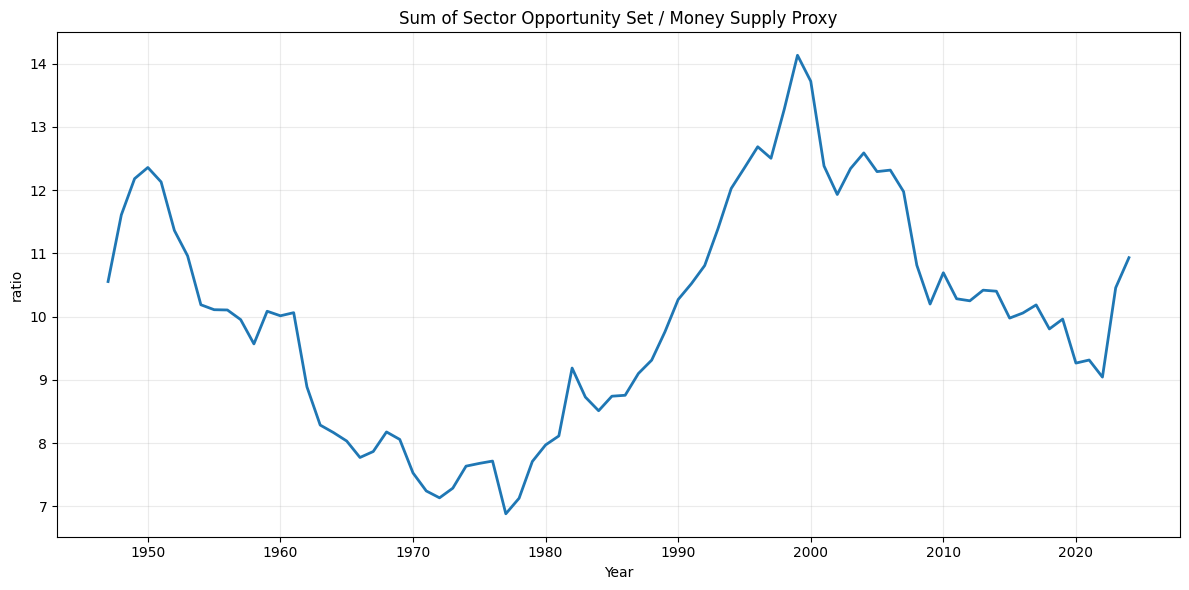

Most recent year with complete coverage across all required series: 2024


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

if "sectors" not in globals():
    raise NameError("sectors is not defined. Run the sector-breakdown cell first.")

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]

        date_col = next((c for c in df.columns if str(c).upper() == "DATE"), df.columns[0])
        value_col = next((c for c in df.columns if str(c).strip().upper() == series_id.upper()), None)
        if value_col is None:
            value_col = next((c for c in df.columns if str(c).strip().upper() != "DATE"), None)
        if value_col is None:
            raise ValueError(f"Could not find value column for {series_id}: {df.columns.tolist()}")

        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.dropna(subset=[date_col]).set_index(date_col)
        df[series_id] = pd.to_numeric(df[value_col], errors="coerce")
        return df[[series_id]]


def to_annual_series(series_id: str) -> pd.Series:
    df = fred_series(series_id).copy()
    if isinstance(df.index, pd.PeriodIndex):
        df.index = df.index.asfreq("Y")
    else:
        df.index = pd.to_datetime(df.index, errors="coerce").to_period("Y")
    s = df.groupby(df.index)[series_id].mean()
    return s.sort_index()


def to_year_series(obj, col: str | None = None) -> pd.Series:
    s = obj[col] if col is not None else obj
    s = pd.to_numeric(s, errors="coerce")
    idx = s.index
    if isinstance(idx, pd.PeriodIndex):
        years = idx.year
    elif isinstance(idx, pd.DatetimeIndex):
        years = idx.year
    else:
        years = pd.to_numeric(pd.Index(idx), errors="coerce")
    out = pd.Series(s.values, index=years, name=s.name)
    out = out[~pd.isna(out.index)]
    out.index = out.index.astype(int)
    return out.groupby(out.index).mean()


sector_sum = sectors.sum(axis=1)
sector_sum = to_year_series(sector_sum).sort_index()
sector_sum = sector_sum[sector_sum.index >= 1947]

money_supply_proxy = (
    to_year_series(to_annual_series("BOGZ1FL703130005A"))
    + to_year_series(to_annual_series("BOGZ1FL703127005A"))
    + to_year_series(to_annual_series("BOGZ1FL713125005A"))
)

aligned = pd.concat(
    [
        sector_sum.rename("sector_sum"),
        money_supply_proxy.rename("money_supply_proxy"),
    ],
    axis=1,
).dropna()

aligned = aligned[aligned.index >= 1947]
most_recent_year = int(aligned.index.max())
aligned = aligned.loc[1947:most_recent_year]

ratio = aligned["sector_sum"] / aligned["money_supply_proxy"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ratio.index, ratio.values, linewidth=2, color="#1f77b4")
ax.set_title("Sum of Sector Opportunity Set / Money Supply Proxy")
ax.set_xlabel("Year")
ax.set_ylabel("ratio")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Most recent year with complete coverage across all required series: {most_recent_year}")


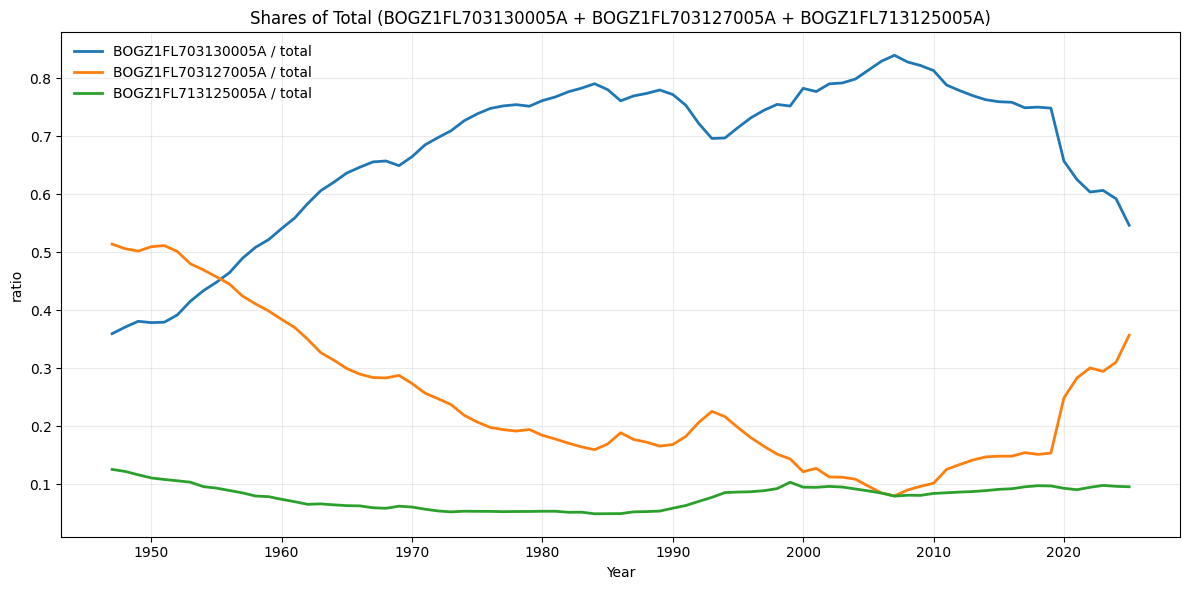

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]

        date_col = next((c for c in df.columns if str(c).upper() == "DATE"), df.columns[0])
        value_col = next((c for c in df.columns if str(c).strip().upper() == series_id.upper()), None)
        if value_col is None:
            value_col = next((c for c in df.columns if str(c).strip().upper() != "DATE"), None)
        if value_col is None:
            raise ValueError(f"Could not find value column for {series_id}: {df.columns.tolist()}")

        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.dropna(subset=[date_col]).set_index(date_col)
        df[series_id] = pd.to_numeric(df[value_col], errors="coerce")
        return df[[series_id]]


def to_annual_series(series_id: str) -> pd.Series:
    df = fred_series(series_id).copy()
    if isinstance(df.index, pd.PeriodIndex):
        df.index = df.index.asfreq("Y")
    else:
        df.index = pd.to_datetime(df.index, errors="coerce").to_period("Y")
    s = df.groupby(df.index)[series_id].mean()
    return s.sort_index()


s_703130 = to_annual_series("BOGZ1FL703130005A")
s_703127 = to_annual_series("BOGZ1FL703127005A")
s_713125 = to_annual_series("BOGZ1FL713125005A")

df = pd.concat(
    [
        s_703130.rename("BOGZ1FL703130005A"),
        s_703127.rename("BOGZ1FL703127005A"),
        s_713125.rename("BOGZ1FL713125005A"),
    ],
    axis=1,
).dropna()

df = df[df.index >= pd.Period("1947", freq="Y")]
df = df[df.index <= pd.Period("2025", freq="Y")]

denom = df["BOGZ1FL703130005A"] + df["BOGZ1FL703127005A"] + df["BOGZ1FL713125005A"]
df = df[denom != 0].copy()
denom = denom[denom != 0]

df["share_703130"] = df["BOGZ1FL703130005A"] / denom
df["share_703127"] = df["BOGZ1FL703127005A"] / denom
df["share_713125"] = df["BOGZ1FL713125005A"] / denom

plot_df = df[["share_703130", "share_703127", "share_713125"]].copy()
plot_df.index = plot_df.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot_df.index, plot_df["share_703130"], linewidth=2, label="BOGZ1FL703130005A / total")
ax.plot(plot_df.index, plot_df["share_703127"], linewidth=2, label="BOGZ1FL703127005A / total")
ax.plot(plot_df.index, plot_df["share_713125"], linewidth=2, label="BOGZ1FL713125005A / total")

ax.set_title("Shares of Total (BOGZ1FL703130005A + BOGZ1FL703127005A + BOGZ1FL713125005A)")
ax.set_xlabel("Year")
ax.set_ylabel("ratio")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


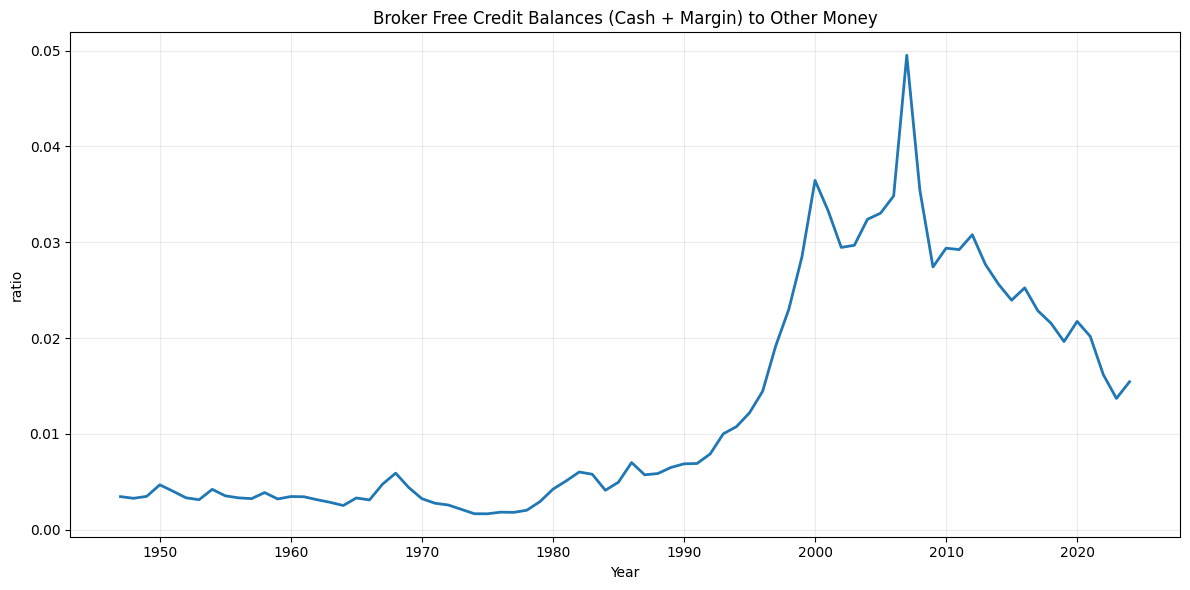

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

if "fred_series" not in globals():
    def fred_series(series_id: str) -> pd.DataFrame:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url)
        df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]

        date_col = next((c for c in df.columns if str(c).upper() == "DATE"), df.columns[0])
        value_col = next((c for c in df.columns if str(c).strip().upper() == series_id.upper()), None)
        if value_col is None:
            value_col = next((c for c in df.columns if str(c).strip().upper() != "DATE"), None)
        if value_col is None:
            raise ValueError(f"Could not find value column for {series_id}: {df.columns.tolist()}")

        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.dropna(subset=[date_col]).set_index(date_col)
        df[series_id] = pd.to_numeric(df[value_col], errors="coerce")
        return df[[series_id]]


def to_annual_series(series_id: str) -> pd.Series:
    df = fred_series(series_id).copy()
    if isinstance(df.index, pd.PeriodIndex):
        df.index = df.index.asfreq("Y")
    else:
        df.index = pd.to_datetime(df.index, errors="coerce").to_period("Y")
    return df.groupby(df.index)[series_id].mean().sort_index()


# Numerator from local revised broker free-credit file (millions of dollars)
broker_path = "broker_free_credit_balances_1947_2025_REVISED.csv"
broker_df = pd.read_csv(broker_path)
broker_df["year"] = pd.to_numeric(broker_df["year"], errors="coerce").astype("Int64")
broker_df["free_credit_total_millions"] = pd.to_numeric(
    broker_df["free_credit_total_millions"], errors="coerce"
)

broker_series = (
    broker_df.set_index("year")["free_credit_total_millions"].dropna().sort_index()
)

# Denominator: other money
other_money = (
    to_annual_series("BOGZ1FL703130005A")
    + to_annual_series("BOGZ1FL703127005A")
    + to_annual_series("BOGZ1FL713125005A")
)
other_money.index = other_money.index.year

aligned = pd.concat(
    [
        broker_series.rename("broker_free_credit_balances"),
        other_money.rename("other_money"),
    ],
    axis=1,
).dropna()
aligned = aligned.loc[1947:2024]
aligned = aligned[aligned["other_money"] != 0]

broker_free_credit_to_other_money = (
    aligned["broker_free_credit_balances"] / aligned["other_money"]
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    broker_free_credit_to_other_money.index,
    broker_free_credit_to_other_money.values,
    linewidth=2,
    color="#1f77b4",
)
ax.set_title("Broker Free Credit Balances (Cash + Margin) to Other Money")
ax.set_xlabel("Year")
ax.set_ylabel("ratio")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


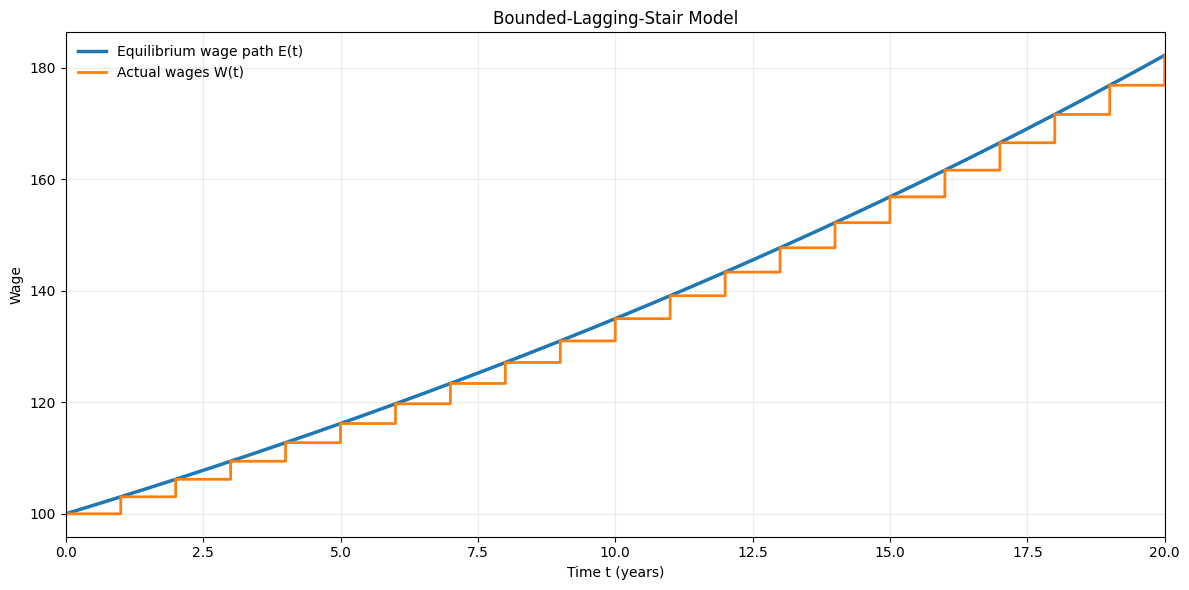

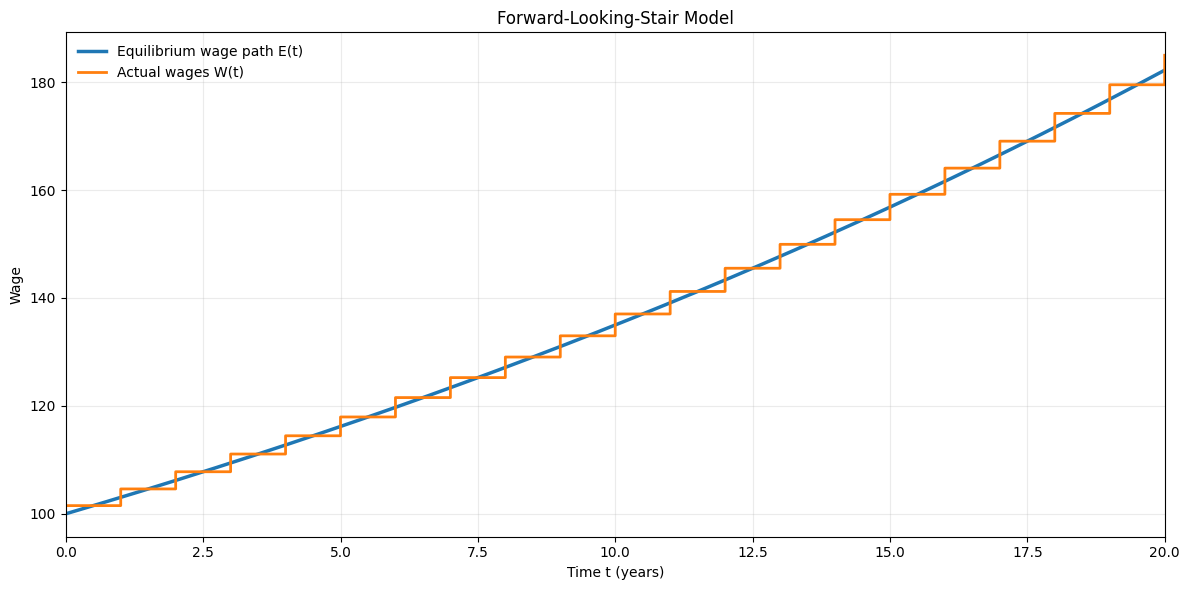

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
A = 100
r = 0.03
delta = 1
T = 20


t = np.linspace(0, T, 2001)
E = A * np.exp(r * t)

# Bounded-lagging stair model: wages reset to current equilibrium at each integer year.
n_lag = np.floor(t / delta)
W_lag = A * np.exp(r * n_lag * delta)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t, E, linewidth=2.5, label="Equilibrium wage path E(t)")
ax.step(t, W_lag, where="post", linewidth=2, label="Actual wages W(t)")
ax.set_title("Bounded-Lagging-Stair Model")
ax.set_xlabel("Time t (years)")
ax.set_ylabel("Wage")
ax.set_xlim(0, T)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# Forward-looking stair model: wages reset to the expected average equilibrium wage
# over the coming contract interval.
n_forward = np.floor(t / delta)
W_forward = (A / (r * delta)) * (
    np.exp(r * (n_forward + 1) * delta) - np.exp(r * n_forward * delta)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t, E, linewidth=2.5, label="Equilibrium wage path E(t)")
ax.step(t, W_forward, where="post", linewidth=2, label="Actual wages W(t)")
ax.set_title("Forward-Looking-Stair Model")
ax.set_xlabel("Time t (years)")
ax.set_ylabel("Wage")
ax.set_xlim(0, T)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

